### Lab 7 ###
Christopher Cook, Davis Lynn, Anekah Kelley, Bonita Davis

In this lab, you will select a prediction task to perform on your dataset, evaluate a sequential architecture and tune hyper-parameters. If any part of the assignment is not clear, ask the instructor to clarify.

__Preparation__ 

[1]Define and prepare your class variables. Use proper variable representations (int, float, one-hot, etc.). Use pre-processing methods (as needed). Describe the final dataset that is used for classification/regression (include a description of any newly formed variables you created). Discuss methods of tokenization in your dataset as well as any decisions to force a specific length of sequence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import re
import itertools
import tensorflow as tf
import nltk
from tqdm import tqdm

from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dropout, Layer, TextVectorization, Dense, GlobalMaxPooling1D, MultiHeadAttention, LayerNormalization # type: ignore
from tensorflow.keras.regularizers import l1_l2 
from nltk.corpus import stopwords
from sklearn.metrics import recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from keras.layers import Embedding # type: ignore
from sklearn.model_selection import StratifiedKFold
mpl.style.use("seaborn-v0_8-deep")
mpl.rcParams["figure.figsize"] = (20, 5)
mpl.rcParams["figure.dpi"] = 100
plt.rcParams["figure.dpi"] = 100
plt.rcParams["lines.linewidth"] = 2

nltk.download("vader_lexicon")
nltk.download("punkt")
nltk.download("stopwords")

nltk.data.path.append('/users/cdcook/nltk_data/tokenizers/punkt')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\davis\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\davis\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\davis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Load dataset
df = pd.read_csv("./file.csv")
df = df.head(50000)
og_shape = df.shape
print(og_shape)

(50000, 3)


In [3]:
df

,Unnamed: 0,tweets,labels
0,0,ChatGPT: Optimizing Language Models for Dialog...,neutral
1,1,"Try talking with ChatGPT, our new AI system wh...",good
2,2,ChatGPT: Optimizing Language Models for Dialog...,neutral
3,3,"THRILLED to share that ChatGPT, our new model ...",good
4,4,"As of 2 minutes ago, @OpenAI released their ne...",bad
...,...,...,...
49995,49995,The ChatGPT hyperbolic hype train is in overdr...,bad
49996,49996,This instance of artificial intelligence has a...,good
49997,49997,Ripple CTO shuts down ChatGPT’s XRP conspiracy...,bad
49998,49998,The Brilliance and Weirdness of ChatGPT https:...,neutral


In [4]:
def cleanText(txt):
      
    #Creates list of possible stopwords from nltk library
    stop = stopwords.words('english')
    
    # Lowercase
    txt = txt.lower()
    
    # Remove stopwords
    txt = ' '.join([word for word in txt.split() if word not in (stop)])
    
    # Remove non-alphabetic characters
    txt = re.sub('[^a-z]',' ',txt)
    return txt  

def cleanNumbers(x):
    digit_map = {
        '0': 'zero',
        '1': 'one',
        '2': 'two',
        '3': 'three',
        '4': 'four',
        '5': 'five',
        '6': 'six',
        '7': 'seven',
        '8': 'eight',
        '9': 'nine'
    }
    
    x = re.sub('[0-9]{7,}', 'millions', x)
    x = re.sub('[0-9]{4,6}', 'thousand', x)
    x = re.sub('[0-9]{3}', 'hundred', x)
    x = re.sub('[0-9]{2}', 'tens', x)
    x = re.sub('[0-9]{1}', 'tens', x)
    x = re.sub(r'\b\d\b', lambda match: digit_map[match.group()], x)

    return x
contraction_dict = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not", "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not", "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",  "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would", "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam", "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have", "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is", "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as", "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would", "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have", "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have", "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are", "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",  "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is", "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have", "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have", "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all", "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have", "you're": "you are", "you've": "you have"}

def _get_contractions(contraction_dict):
    contraction_re = re.compile('(%s)' % '|'.join(contraction_dict.keys()))
    return contraction_dict, contraction_re

contractions, contractions_re = _get_contractions(contraction_dict)

def replaceContractions(text):
    def replace(match):
        return contractions[match.group(0)]
    return contractions_re.sub(replace, text)


size_mini = 1000

def pre_process(df):
    """
    Parameters:
    - df (pd.Dataframe): The DataFrame to be preprocessed

    Returns: 
    - df (pd.DataFrame): The DataFrame after preprocessed

    """
    # Remove the 'Unnamed: 0' column, if it exists, as it's usually an artifact
    df = df.drop(["Unnamed: 0"], axis=1)
    
    # Map 'labels' values from 'bad'/'good' to 1/0, and set 'neutral' to NaN
    df["labels"] = df["labels"].map({"bad": 1, "good": 0, "neutral": None})
    
    # Drop rows with NaN values in 'labels'
    df = df.dropna(subset=["labels"])

    print("We have kept", (df.shape[0]/og_shape[0])*100, "% of the data")

    # Cleaning the text, numbers, and replacing contractions
    df['tweets'] = df['tweets'].apply(cleanText)
    df['tweets'] = df["tweets"].apply(cleanNumbers)
    df['tweets'] = df["tweets"].apply(replaceContractions)

    return df

In [5]:
def num_characters(df, col_name):
    """
    Adds a new column to the DataFrame containing the number of characters in each message.

    Parameters:
    - df: DataFrame. The DataFrame to which the new column will be added.
    - col_name: str. The name of the column containing the messages.

    Returns:
    - DataFrame. The original DataFrame with a new column added.
    """

    df["Characters"] = df[col_name].apply(len)
    return df


def num_sentences(df, col_name):
    """
    Adds a new column to the DataFrame containing the number of sentences in each message.

    Parameters:
    - df: DataFrame. The DataFrame to which the new column will be added.
    - col_name: str. The name of the column containing the messages.

    Returns:
    - DataFrame. The original DataFrame with a new column added.
    """
    df["Sentences"] = df[col_name].apply(lambda x: len(nltk.sent_tokenize(x)))
    return df


def num_words(df, col_name):
    """
    Adds a new column to the DataFrame containing the number of words in each message.

    Parameters:
    - df: DataFrame. The DataFrame to which the new column will be added.
    - col_name: str. The name of the column containing the messages.

    Returns:
    - DataFrame. The original DataFrame with a new column added.
    """
    df["Words"] = df[col_name].apply(lambda x: len(nltk.word_tokenize(x)))
    return df

In [6]:
df = pre_process(df)

We have kept 74.652 % of the data


In [7]:
df = num_characters(df, "tweets")
df = num_sentences(df, "tweets")
df = num_words(df, "tweets")
df

,tweets,labels,Characters,Sentences,Words
1,try talking chatgpt new ai system optimized d...,0.0,107,1,19
3,thrilled share chatgpt new model optimized di...,0.0,158,1,24
4,minutes ago openai released new chatgpt ...,1.0,112,1,21
5,launched chatgpt new ai system optimized dial...,0.0,113,1,22
6,minutes ago openai released new chatgpt ...,1.0,144,1,31
...,...,...,...,...,...
49994,can t even use regular gpt chatgpt usage bummer,1.0,49,1,9
49995,chatgpt hyperbolic hype train overdrive one...,1.0,210,1,36
49996,instance artificial intelligence fantastic ans...,0.0,117,1,18
49997,ripple cto shuts chatgpt s xrp conspiracy theo...,1.0,72,1,13


In [8]:
def plot_distribution_features(df, features, col_name):
    """
    Plot distributions of specified features in a DataFrame, comparing positive and negative tweets.

    Parameters:
    - df: DataFrame containing the data.
    - features: List of strings, names of the columns for which to plot the distributions.

    Each feature's distribution is plotted in a separate row, with 'good' tweets in blue and 'bad' tweets in pink.
    """
    # Create a figure with subplots arranged in 3 rows and 1 column
    fig, axes = plt.subplots(
        nrows=len(features), ncols=1, figsize=(15, 6 * len(features))
    )

    for i, feature in enumerate(features):
        # Plot distribution for 'good' tweets
        sns.histplot(
            df[df["labels"] == 0][feature],
            kde=True,
            color="#66b3ff",
            label="Positive",
            ax=axes[i],
        )
        # Plot distribution for 'bad' tweets
        sns.histplot(
            df[df["labels"] == 1][feature],
            kde=True,
            color="#ff9999",
            label="Negative",
            ax=axes[i],
        )
        # Setting the title for each subplot
        axes[i].set_title(f"{feature} Distribution for {col_name} dataset")
        # Setting the labels for each subplot
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Count")
        # Adding legend to each subplot
        axes[i].legend()

    # Adjust layout
    plt.tight_layout()
    plt.show()

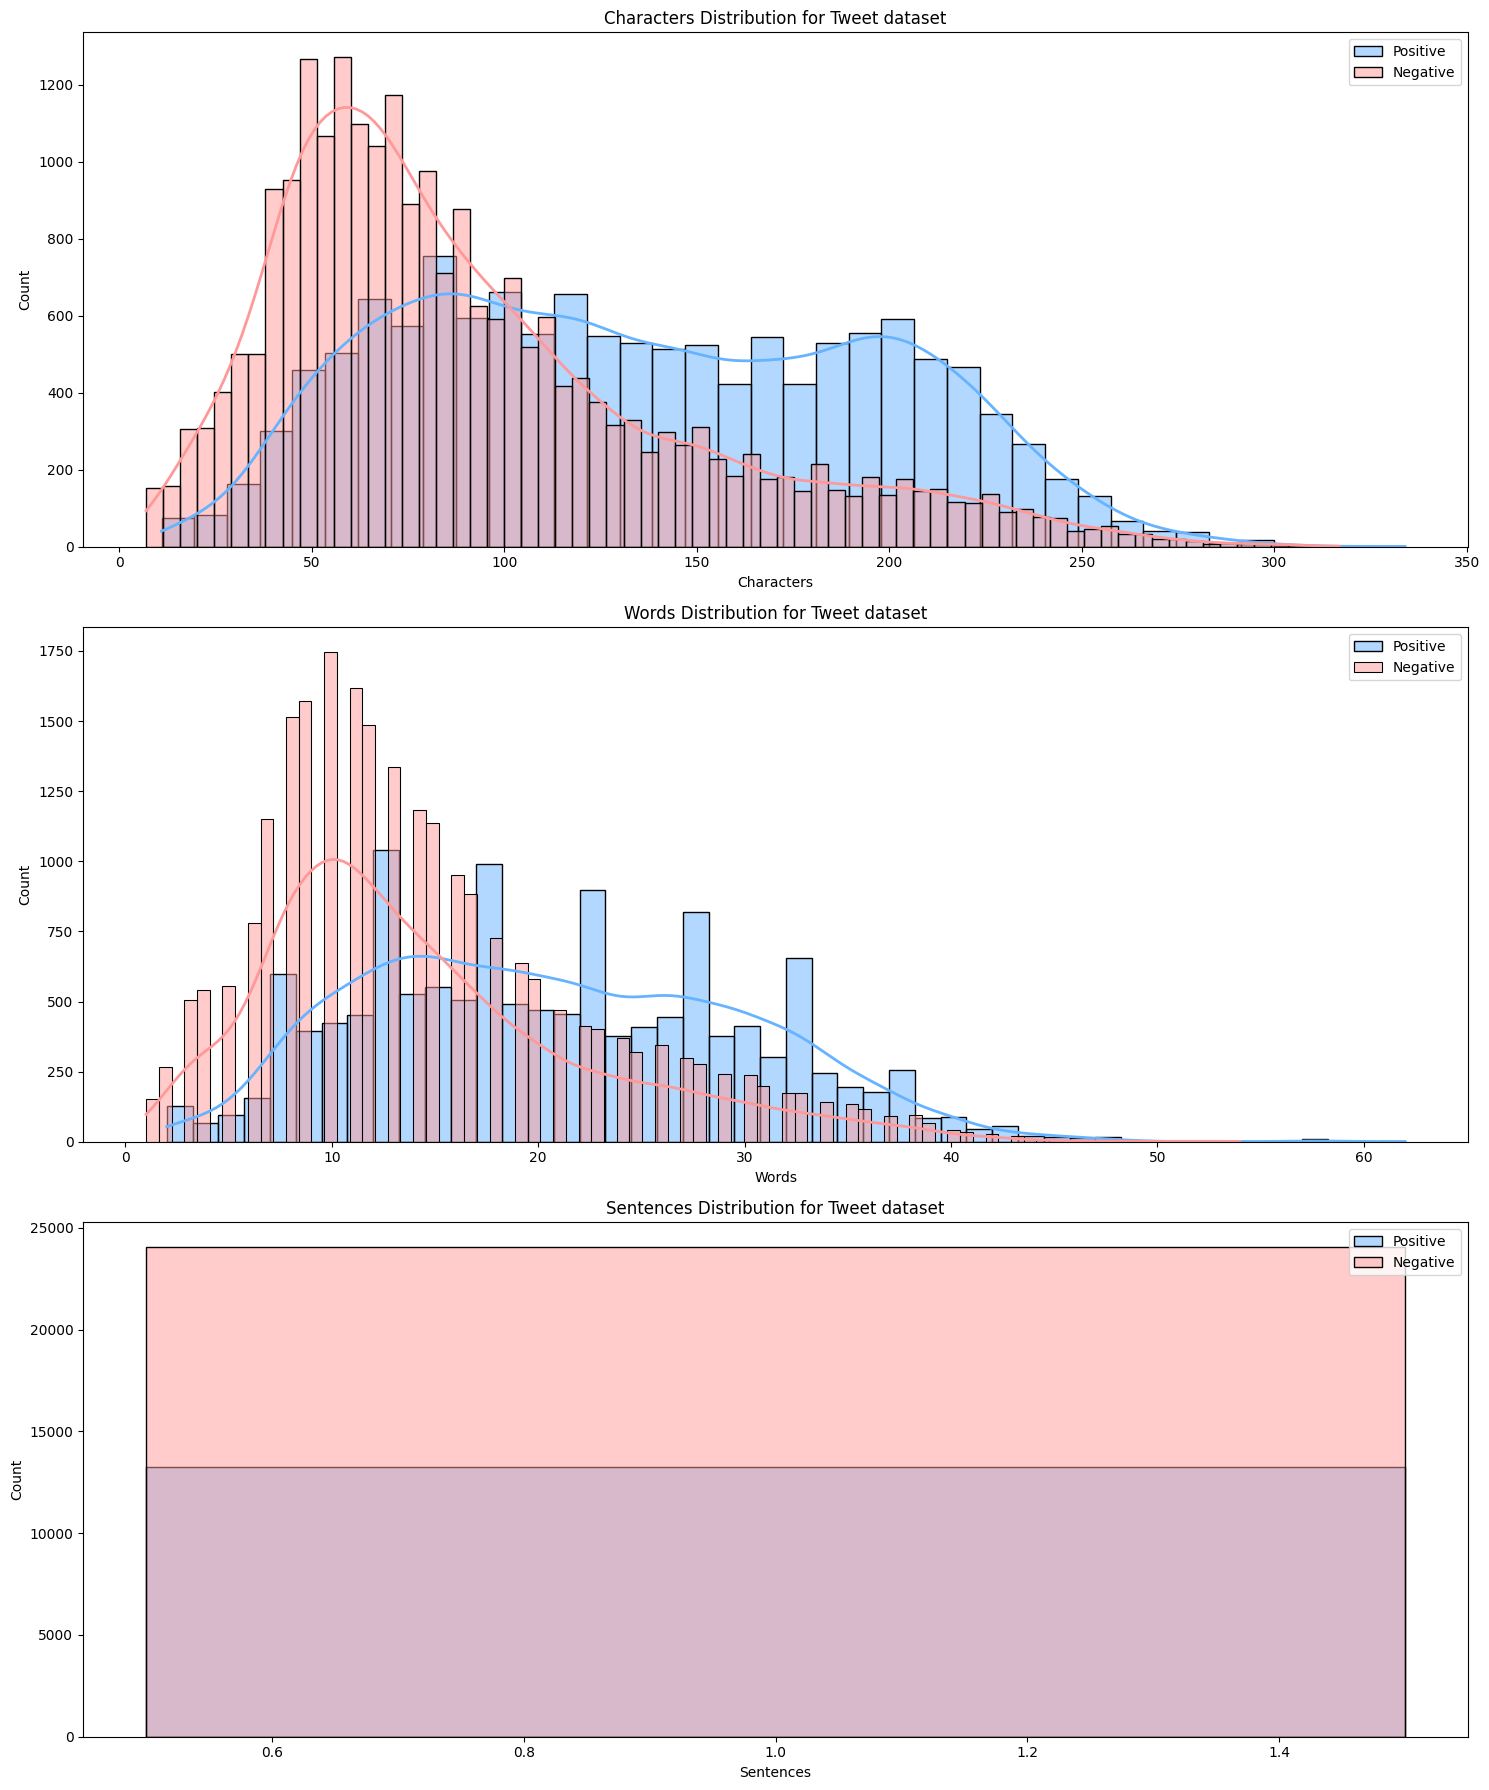

In [9]:
# List of features to plot
features = ["Characters", "Words", "Sentences"]

# Call the function
plot_distribution_features(df, features, "Tweet")

In [10]:
df['text_length'] = df['tweets'].apply(lambda x: len(x.split()))

# Determine the 95th percentile of these lengths
sequence_length_95 = np.percentile(df['text_length'], 95)

sequence_length = int(np.ceil(sequence_length_95))

print(f"Length covering at least 95% of the Tweets: {sequence_length}")
df = df.drop(columns=["text_length"])
print("The kept sequence is:", sequence_length, "words")

Length covering at least 95% of the Tweets: 34
The kept sequence is: 34 words


In [11]:
max_features = 10000

vectorization = TextVectorization(standardize="lower_and_strip_punctuation", 
                                  max_tokens=max_features, 
                                  output_mode='int', 
                                  output_sequence_length=sequence_length)
vectorization.adapt(df["tweets"])

words_database = vectorization.get_vocabulary()
database_index = {word: index for index, word in enumerate(words_database)}

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding
import numpy as np
from tqdm import tqdm

# Define max_features and sequence length
max_features = 20000
sequence_length = 100

# Tokenizer to generate word index
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(df['tweets'])
database_index = tokenizer.word_index

# Load GloVe embeddings
def load_glove_index():
    EMBEDDING_FILE = 'glove.twitter.27B.200d.txt'
    def get_coefs(word, *arr): return word, np.asarray(arr, dtype='float32')
    embeddings_index = dict(get_coefs(*o.split(" ")) for o in open(EMBEDDING_FILE, 'r', encoding='utf-8'))
    return embeddings_index

glove_embedding_index_twitter = load_glove_index()

# Create embedding matrix
def create_glove(word_index, embeddings_index):
    all_embs = list(embeddings_index.values())
    embed_size = all_embs[0].shape[0]
    nb_words = min(max_features, len(word_index))
    embedding_matrix = np.random.normal(0, 1, (nb_words, embed_size))

    count_found = nb_words
    for word, i in tqdm(word_index.items()):
        if i >= max_features: continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None: 
            embedding_matrix[i] = embedding_vector
        else:
            if word.islower():
                embedding_vector = embeddings_index.get(word.capitalize())
                if embedding_vector is not None: 
                    embedding_matrix[i] = embedding_vector
                else:
                    count_found -= 1
            else:
                count_found -= 1
    print("We found", count_found, "words")
    return embedding_matrix

adapted_glove_twitter = create_glove(database_index, glove_embedding_index_twitter)

# Define embedding layer
embedding_dim = 200
embedding_layer = Embedding(
    input_dim=max_features, 
    output_dim=embedding_dim, 
    weights=[adapted_glove_twitter], 
    input_length=sequence_length, 
    trainable=False
)

100%|██████████| 63531/63531 [00:00<00:00, 2155282.30it/s]

We found 16024 words



C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


__Discuss methods of tokenization in your dataset as well as any decisions to force a specific length of sequence.__

We are using the tokenize program from nltk. This package allows us to tokenize our tweets by each word within the tweet, remove stopwords, lowercase the sentence, and remove non-alphabetic characters. We found the number of tokens that encompass 95% of the dataset, 35 tokens, and adapted the entire dataset to that number by adding tokens to bring the tweets up to 35 tokens or truncating the tokens down to 35. Bringing the values to the same number of tokens allows the values to be passed into our model consistently, ensuring good performance.

__Choose and explain what metric(s) you will use to evaluate your algorithm’s performance.__

We have decided to use the ROC-AUC score to evaluate the performance of our model. AUC provides a more nuanced performance evaluation, particularly in distinguishing between classes at various decision thresholds. While accuracy measures the overall correctness, AUC focuses on the model's ability to discriminate between classes, making it an ideal metric for understanding how well the model performs across different thresholds. Furthermore, our dataset is unbalanced, with only about a third of the dataset comprised of positive tweets, and this will give us insight into how the model performs across the classes despite the imbalance.

False Positives or Negatives are not more important than the other when analyzing tweets' sentiment; thus, we do not believe Precision or Recall is effective for evaluation.

__Choose the method you will use for dividing your data into training and testing__

We chose to divide our data using stratified 10-fold cross-validation because this method is best suited for our prediction task. Stratified 10-fold cross-validation ensures that each fold in the cross-validation process maintains the same proportion of samples from each class as in the full dataset. Since we have 18 character classes, this method ensures that each training and test subset is representative of the overall distribution of characters. This is important as we want to ensure the model is trained and tested on balanced data to avoid any potential biases that could happen if there were classes that are underrepresented in certain folds.

Furthermore, by using stratified 10-fold cross-validation, we ensure that every data point is used both for training and testing across different folds, allowing the model to be evaluated on multiple splits of the data. This reduces the variance of the performance estimate, providing a more reliable understanding of how the model will perform on unseen data. With 10 folds, each model is tested on a different partition, and we can compute an average accuracy (and AUC score) across all folds to get a more stable performance metric.

Stratified 10-fold cross-validation is a realistic mirroring of how an algorithm would be evaluated in practice, especially when the goal is to ensure the model generalizes well to unseen data. In real-world applications, models are often deployed to classify new, unseen data. By using this method, we mimic this process by repeatedly testing the model on data that it had not seen during training. This iterative testing approach helps to evaluate how well the model generalizes across different subsets of the dataset and provides a realistic simulation of how the model would be deployed.

__Modeling__

[3]Investigate at least two different sequential network architectures (e.g., a CNN and a Transformer). Alternatively, you may also choose a recurrent network and Transformer network. Be sure to use an embedding layer (try to use a pre-trained embedding, if possible). Adjust one hyper-parameter of each network to potentially improve generalization performance (train a total of at least four models). Visualize the performance of training and validation sets versus the training iterations, showing that the models converged.

In [13]:
from tensorflow.keras.layers import TextVectorization

# Parameters for vectorization
max_tokens = 20000  # Maximum number of unique tokens
sequence_length = 100  # Length of sequences to pad or truncate to

# Define the TextVectorization layer
vectorization = TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=sequence_length
)

# Adapt the vectorization layer to your dataset
# Assuming `text_dataset` is a tf.data.Dataset of raw text
vectorization.adapt(df['tweets'])

def gru_model():
    model = Sequential()
    model.add(tf.keras.Input(shape=(1,), dtype=tf.string))  # Input layer for raw strings
    model.add(vectorization)
    model.add(embedding_layer)
    model.add(GRU(128, return_sequences=True))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu', kernel_regularizer=l1_l2(0.01)))
    model.add(Dense(1, activation='sigmoid'))

    return model

def lstm_model():
    model = Sequential()
    model.add(tf.keras.Input(shape=(1,), dtype=tf.string))  # Input layer for raw strings
    model.add(vectorization)
    model.add(embedding_layer)
    model.add(LSTM(128, return_sequences=True))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu', kernel_regularizer=l1_l2(0.01)))
    model.add(Dense(1, activation='sigmoid'))

    return model

def rnn_model():
    model = Sequential()
    model.add(tf.keras.Input(shape=(1,), dtype=tf.string))  # Input layer for raw strings
    model.add(vectorization)
    model.add(embedding_layer)
    model.add(SimpleRNN(128, return_sequences=True))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu', kernel_regularizer=l1_l2(0.01)))
    model.add(Dense(1, activation='sigmoid'))

    return model

class TransformerBlock(Layer): # inherit from Keras Layer
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.2):
        super().__init__()
        # setup the model heads and feedforward network
        self.att = MultiHeadAttention(num_heads=num_heads, 
                                      key_dim=embed_dim)
        
        # make a two layer network that processes the attention
        self.ffn = Sequential()
        self.ffn.add( Dense(ff_dim, activation='relu') )
        self.ffn.add( Dense(embed_dim) )
        
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=True):
        # apply the layers as needed (similar to PyTorch)
        
        # get the attention output from multi heads
        # Using same inpout here is self-attention
        # call inputs are (query, value, key) 
        # if only two inputs given, value and key are assumed the same
        attn_output = self.att(inputs, inputs)
        
        # create residual output, with attention
        out1 = self.layernorm1(inputs + attn_output)
        
        # apply dropout if training
        out1 = self.dropout1(out1, training=training)
        
        # place through feed forward after layer norm
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        
        # apply dropout if training
        out2 = self.dropout2(out2, training=training)
        #return the residual from Dense layer
        return out2
    
    
class TokenAndPositionEmbedding(Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        # create two embeddings 
        # one for processing the tokens (words)
        self.token_emb = Embedding(input_dim=vocab_size, 
                                   output_dim=embed_dim)
        # another embedding for processing the position
        self.pos_emb = Embedding(input_dim=maxlen, 
                                 output_dim=embed_dim)

    def call(self, x):
        # create a static position measure (input)
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        # positions now goes from 0 to 500 (for IMdB) by 1
        positions = self.pos_emb(positions)# embed these positions
        x = self.token_emb(x) # embed the tokens
        return x + positions # add embeddngs to get final embedding

def transformer_model():
    embed_dim = embedding_dim  # Assuming you are using GloVe embeddings with dimension 200
    num_heads = 1
    ff_dim = 32

    inputs = tf.keras.Input(shape=(sequence_length,), dtype=tf.int32)  # Use dtype=tf.string for token sequences
    x = inputs
    x = TokenAndPositionEmbedding(sequence_length, max_features, embed_dim)(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(20, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

In [14]:
def train_and_evaluate_model(model, train_df, test_df, epochs=20):

    model.summary()
    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model and store the training history
    history = model.fit(train_df['tweets'], train_df['labels'], epochs=epochs, validation_data=(test_df['tweets'], test_df['labels']))

    # Return the training history and the trained model
    return history, model

# Function to plot the training and validation accuracy and loss
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.suptitle(title)

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

In [15]:
model_variations = [
    (rnn_model),
    (lstm_model),
    (gru_model),
    # (transformer_model) - Added below b/c different architecture
]

# Train and evaluate all model variations

epochs = 20

histories = []
models = []
## Implementing Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
for train_index, test_index in skf.split(df['tweets'], df['labels']):
    train_df, test_df = df.iloc[train_index], df.iloc[test_index]

    for model_func in model_variations:
        _model = model_func()
        history, model = train_and_evaluate_model(model=_model, train_df=train_df, test_df=test_df, epochs=epochs)
        histories.append(history)
        models.append(model)


for model_func in model_variations:
    _model = model_func()
    history, model = train_and_evaluate_model(model=_model, train_df=train_df, test_df=test_df, epochs=epochs)
    histories.append(history)
    models.append(model)

# Add the transformer model to the list of models
train_sequences = vectorization(train_df['tweets'])
test_sequences = vectorization(test_df['tweets'])

trans_model = transformer_model()

trans_model.summary()
trans_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
trans_history = trans_model.fit(train_sequences, train_df['labels'], epochs=epochs, validation_data=(test_sequences, test_df['labels']))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 200)       │     4,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100, 128)       │        42,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,433 (15.45 MB)

 Trainable params: 50,433 (197.00 KB)

 Non-trainable params: 4,000,000 (15.26 MB)

ValueError: Invalid dtype: object

In [34]:
# Visualize the performance of all model variations
for i, history in enumerate(histories):
    model_func = model_variations[i]
    title = f"{model_func.__name__}"
    plot_history(history, title=f"{title}")

# Plot Transformer Model as well
plot_history(trans_history, title=f"Transformer Model With 1 Multi-headed Self Attention Layer")

NameError: name 'trans_history' is not defined

[1]Using the best parameters and architecture from the Transformer in the previous step, add a second Multi-headed self attention layer to your network. That is, the input to the second attention layer should be the output sequence of the first attention layer.  Visualize the performance of training and validation sets versus the training iterations, showing that the model converged.

In [ ]:
def transformer_model2():
    embed_dim = embedding_dim  # Assuming you are using GloVe embeddings with dimension 200
    num_heads = 2
    ff_dim = 32

    inputs = tf.keras.Input(shape=(sequence_length,), dtype=tf.int32)  # Use dtype=tf.string for token sequences
    x = inputs
    x = TokenAndPositionEmbedding(sequence_length, max_features, embed_dim)(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(20, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

trans_model2 = transformer_model2()

trans_model2.summary()
trans_model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
trans_history2 = trans_model2.fit(train_sequences, train_df['label'], epochs=epochs, validation_data=(test_sequences, test_df['label']))

plot_history(trans_history2, title=f"Transformer With 2 Multi-headed Self Attention Layer")

[2]Use the method of train/test splitting and evaluation criteria that you argued for at the beginning of the lab. Visualize the results of all the models you trained.  Use proper statistical comparison techniques to determine which method(s) is (are) superior.  


In [ ]:
# Calculate evaluation metrics for all model variations
evaluation_results = []


X_test = test_df['tweets']
y_test = test_df['labels']


for model in models:
    y_pred = model.predict(X_test)  # Assuming X_test and y_test are the test data
    y_pred_binary = (y_pred > 0.5).astype(int)  # Convert probabilities to binary predictions

    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp)
    auc_roc = roc_auc_score(y_test, y_pred)

    evaluation_results.append((recall, f1, specificity, auc_roc))

In [ ]:
for result in evaluation_results:
    print(result)


def calculate_metrics_for_transformer_model(trans_model):
    X_test = test_sequences
    y_pred = trans_model.predict(X_test) 
    y_pred_binary = (y_pred > 0.5).astype(int)

    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp)
    auc_roc = roc_auc_score(y_test, y_pred)

    return [recall, f1, specificity, auc_roc]

evaluation_results_transformer_1 = calculate_metrics_for_transformer_model(trans_model)
evaluation_results_transformer_2 = calculate_metrics_for_transformer_model(trans_model2)

In [ ]:
# Visualize the evaluation metrics
metric_names = ['Recall', 'F1 Score', 'Specificity', 'AUC-ROC']

for idx, (model_func) in enumerate(model_variations):
    title = f"{model_func.__name__}"
    plt.suptitle(title)
    for j, metric_name in enumerate(metric_names):
        metric_value = evaluation_results[idx][j]
        plt.subplot(1, len(metric_names), j+1)
        plt.boxplot([metric_value])
        plt.title(metric_name)
        plt.xlabel('Model Variation')

    plt.show()

# Transformer 1
plt.suptitle(f"Transformer Model with 1 Multi-Head")
for j, metric_name in enumerate(metric_names):
    metric_value = evaluation_results_transformer_1[j]
    plt.subplot(1, len(metric_names), j+1)
    plt.boxplot([metric_value])
    plt.title(metric_name)
    plt.xlabel('Model Variation')

plt.show()

# Transformer 2
plt.suptitle(f"Transformer Model with 2 Multi-Head")
for j, metric_name in enumerate(metric_names):
    metric_value = evaluation_results_transformer_2[j]
    plt.subplot(1, len(metric_names), j+1)
    plt.boxplot([metric_value])
    plt.title(metric_name)
    plt.xlabel('Model Variation')
plt.show()

In [ ]:
def plot_confusion_matrix(cm, classes, title="Confusion matrix"):
    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
        )

    plt.tight_layout()
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.grid(False)
    plt.show()

classes = ["Positive", "Negative"]

for idx, (model) in enumerate(models):
    model_func = model_variations[idx]
    title = f"{model_func.__name__}"

    # Calculate confusion matrix
    pred = model.predict(test_df['tweets'])
    y_pred_binary = (pred > 0.5).astype(int)  # Convert probabilities to binary predictions
    cm = confusion_matrix(test_df['labels'], y_pred_binary)
    plot_confusion_matrix(cm, classes, title)

# Transformer Model with 1 Multi-Head
predictions1 = trans_model.predict(test_sequences)
predicted_labels1 = (predictions1 > 0.5).astype(int)
trans_conf_matrix = confusion_matrix(test_df['labels'], predicted_labels1)
plot_confusion_matrix(trans_conf_matrix, classes, title="Transformer Model With 1 Multi-Head")

# Transformer Model with 2 Multi-Head
predictions2 = trans_model2.predict(test_sequences)
predicted_labels2 = (predictions2 > 0.5).astype(int)
trans_conf_matrix2 = confusion_matrix(test_df['labels'], predicted_labels2)
plot_confusion_matrix(trans_conf_matrix2, classes, title="Transformer Model With 2 Multi-Head")

__Exceptional Work__

[1]Use the pre-trained ConceptNet Numberbatch embedding and compare to pre-trained GloVe. Which method is better for your specific application?